# LightGBM Only - Network Slicing 5G

This notebook trains and evaluates only a LightGBM multiclass model on the 5G network slicing dataset.

In [8]:
# Uncomment if needed
# !pip install kagglehub lightgbm

In [9]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
import lightgbm as lgb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score

In [10]:
# Load dataset
path = kagglehub.dataset_download("amohankumar/network-slicing-in-5g")
df = pd.read_csv(path + "/train_dataset.csv")
print("Path to dataset files:", path)
print("Data shape:", df.shape)
df.head()

Path to dataset files: C:\Users\gaming\.cache\kagglehub\datasets\amohankumar\network-slicing-in-5g\versions\1
Data shape: (31583, 17)


,LTE/5g Category,Time,Packet Loss Rate,Packet delay,IoT,LTE/5G,GBR,Non-GBR,AR/VR/Gaming,Healthcare,Industry 4.0,IoT Devices,Public Safety,Smart City & Home,Smart Transportation,Smartphone,slice Type
0,14,0,0.000001,10,1,0,0,1,0,0,0,0,1,0,0,0,3
1,18,20,0.001000,100,0,1,1,0,1,0,0,0,0,0,0,0,1
2,17,14,0.000001,300,0,1,0,1,0,0,0,0,0,0,0,1,1
3,3,17,0.010000,100,0,1,0,1,0,0,0,0,0,0,0,1,1
4,9,4,0.010000,50,1,0,0,1,0,0,0,0,0,1,0,0,2


In [11]:
# Keep only selected features and target
selected_features = [
    "LTE/5g Category",
    "Packet Loss Rate",
    "Packet delay",
    "Smartphone",
    "IoT Devices",
    "GBR"
]
target_col = "slice Type"

X = df[selected_features].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=12,
    stratify=y
)

# Label encode target for multiclass LightGBM
label_encoder = LabelEncoder()
y_train_lgbm = label_encoder.fit_transform(np.asarray(y_train).ravel())
y_test_lgbm = label_encoder.transform(np.asarray(y_test).ravel())

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Classes:", label_encoder.classes_)

X_train shape: (22108, 6)
X_test shape: (9475, 6)
Classes: [1 2 3]


In [12]:
# Train/evaluate across different n_estimators
params = [5, 10, 15, 20, 25, 30, 35, 40]

train_accuracy_scores = []
test_accuracy_scores = []
train_precision_scores = []
test_precision_scores = []
train_recall_scores = []
test_recall_scores = []
train_f1_scores = []
test_f1_scores = []
exec_times = []

num_classes_lgbm = len(np.unique(y_train_lgbm))

for n_estimators_val in params:
    start_time = time.time()

    model = lgb.LGBMClassifier(
        objective="multiclass",
        num_class=num_classes_lgbm,
        n_estimators=n_estimators_val,
        random_state=12,
        verbose=-1
    )

    model.fit(X_train, y_train_lgbm)
    exec_time = time.time() - start_time

    train_accuracy = model.score(X_train, y_train_lgbm)
    test_accuracy = model.score(X_test, y_test_lgbm)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_precision = precision_score(y_train_lgbm, y_train_pred, average="weighted", zero_division=0)
    test_precision = precision_score(y_test_lgbm, y_test_pred, average="weighted", zero_division=0)
    train_recall = recall_score(y_train_lgbm, y_train_pred, average="weighted", zero_division=0)
    test_recall = recall_score(y_test_lgbm, y_test_pred, average="weighted", zero_division=0)
    train_f1 = f1_score(y_train_lgbm, y_train_pred, average="weighted", zero_division=0)
    test_f1 = f1_score(y_test_lgbm, y_test_pred, average="weighted", zero_division=0)

    train_accuracy_scores.append(train_accuracy)
    test_accuracy_scores.append(test_accuracy)
    train_precision_scores.append(train_precision)
    test_precision_scores.append(test_precision)
    train_recall_scores.append(train_recall)
    test_recall_scores.append(test_recall)
    train_f1_scores.append(train_f1)
    test_f1_scores.append(test_f1)
    exec_times.append(exec_time)

    print(f"n_estimators = {n_estimators_val}")
    print(f"  Train -> Acc: {train_accuracy:.4f} | Prec: {train_precision:.4f} | Rec: {train_recall:.4f} | F1: {train_f1:.4f}")
    print(f"  Test  -> Acc: {test_accuracy:.4f} | Prec: {test_precision:.4f} | Rec: {test_recall:.4f} | F1: {test_f1:.4f}")
    print(f"  Time: {exec_time:.4f} s")
    print("-" * 70)

results_df = pd.DataFrame({
    "n_estimators": params,
    "train_accuracy": train_accuracy_scores,
    "test_accuracy": test_accuracy_scores,
    "train_precision": train_precision_scores,
    "test_precision": test_precision_scores,
    "train_recall": train_recall_scores,
    "test_recall": test_recall_scores,
    "train_f1": train_f1_scores,
    "test_f1": test_f1_scores,
    "exec_time_s": exec_times
})

results_df

n_estimators = 5
  Train -> Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000
  Test  -> Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000
  Time: 0.0169 s
----------------------------------------------------------------------
n_estimators = 10
  Train -> Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000
  Test  -> Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000
  Time: 0.0176 s
----------------------------------------------------------------------
n_estimators = 15
  Train -> Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000
  Test  -> Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000
  Time: 0.0231 s
----------------------------------------------------------------------
n_estimators = 20
  Train -> Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000
  Test  -> Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000
  Time: 0.0271 s
----------------------------------------------------------------------
n_estimators = 25
  Train -> Acc: 1.0000 | Prec: 1.0000 |

,n_estimators,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,exec_time_s
0,5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.016919
1,10,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.017627
2,15,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.023111
3,20,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.027122
4,25,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.034038
5,30,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.036562
6,35,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.041921
7,40,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.049555


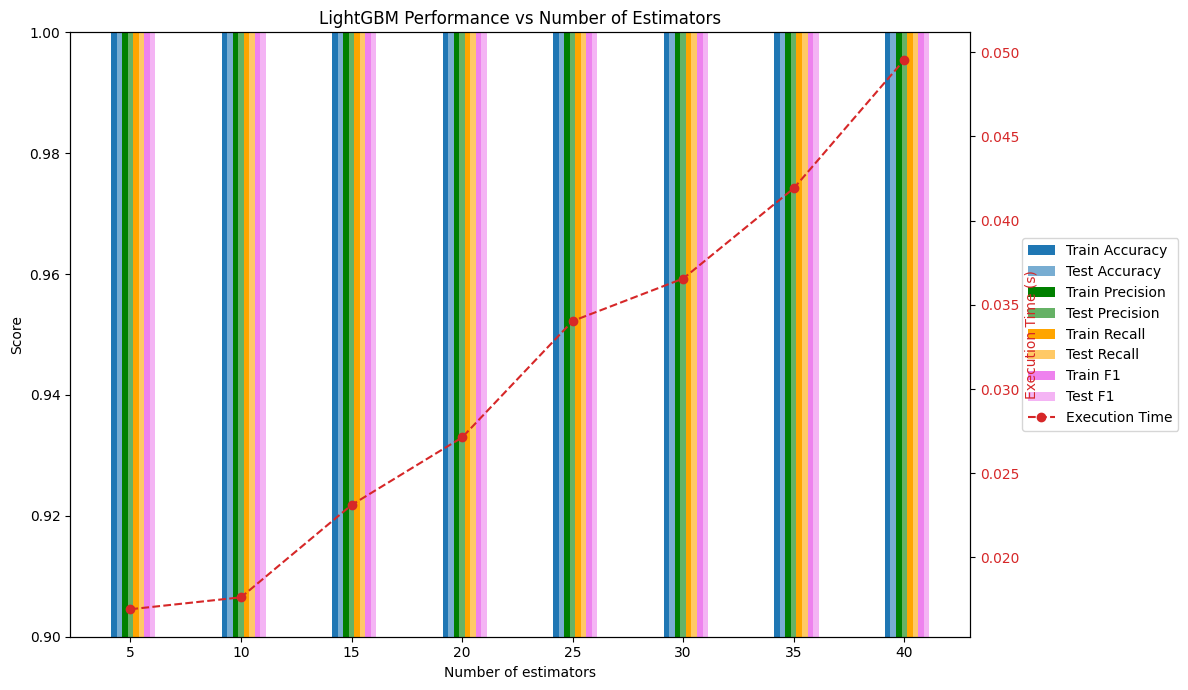

In [13]:
# Plot metrics and execution time
fig, ax1 = plt.subplots(figsize=(12, 7))
positions = np.arange(len(params))
bar_width = 0.05

ax1.bar(positions - 3 * bar_width, train_accuracy_scores, width=bar_width, color="tab:blue", label="Train Accuracy")
ax1.bar(positions - 2 * bar_width, test_accuracy_scores, width=bar_width, color="tab:blue", alpha=0.6, label="Test Accuracy")
ax1.bar(positions - bar_width, train_precision_scores, width=bar_width, color="green", label="Train Precision")
ax1.bar(positions, test_precision_scores, width=bar_width, color="green", alpha=0.6, label="Test Precision")
ax1.bar(positions + bar_width, train_recall_scores, width=bar_width, color="orange", label="Train Recall")
ax1.bar(positions + 2 * bar_width, test_recall_scores, width=bar_width, color="orange", alpha=0.6, label="Test Recall")
ax1.bar(positions + 3 * bar_width, train_f1_scores, width=bar_width, color="violet", label="Train F1")
ax1.bar(positions + 4 * bar_width, test_f1_scores, width=bar_width, color="violet", alpha=0.6, label="Test F1")

ax1.set_xticks(positions)
ax1.set_xticklabels(params)
ax1.set_xlabel("Number of estimators")
ax1.set_ylabel("Score")
ax1.set_ylim([0.90, 1.00])

ax2 = ax1.twinx()
ax2.plot(positions, exec_times, color="tab:red", marker="o", linestyle="--", label="Execution Time")
ax2.set_ylabel("Execution Time (s)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="center left", bbox_to_anchor=(1.05, 0.5))

plt.title("LightGBM Performance vs Number of Estimators")
fig.tight_layout()
plt.show()

In [14]:
best_idx = int(np.argmax(results_df["test_accuracy"].values))
best_row = results_df.iloc[best_idx]

print("Best configuration by test accuracy:")
print(best_row.to_string())

Best configuration by test accuracy:
n_estimators       5.000000
train_accuracy     1.000000
test_accuracy      1.000000
train_precision    1.000000
test_precision     1.000000
train_recall       1.000000
test_recall        1.000000
train_f1           1.000000
test_f1            1.000000
exec_time_s        0.016919
